
# PART B: ANN FOR CLASSIFICATION (Breast Cancer Dataset)


In [1]:
# Student Identifier
STUDENT_ROLL_NO = "24BAD047"  # <--- Replace with your Roll Number
print(f"Part B - Student Roll No: {STUDENT_ROLL_NO}\n" + "="*50)

Part B - Student Roll No: 24BAD047


In [2]:
# 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

In [3]:
# 2. Load Dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

In [4]:
# 3. Split Dataset (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# 4. Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
# 5. Build ANN Model Architecture (Using Input layer to prevent UserWarning)
model_clf = keras.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(16, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
])

In [7]:
model_clf.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
# 7. Train Model
history = model_clf.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=16,
    verbose=1
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - accuracy: 0.4066 - loss: 0.6694 - val_accuracy: 0.5385 - val_loss: 0.5703
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.7253 - loss: 0.5003 - val_accuracy: 0.8571 - val_loss: 0.4854
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9258 - loss: 0.4103 - val_accuracy: 0.9011 - val_loss: 0.4072
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9560 - loss: 0.3191 - val_accuracy: 0.9231 - val_loss: 0.3086
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9588 - loss: 0.2232 - val_accuracy: 0.9560 - val_loss: 0.2198
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9725 - loss: 0.1533 - val_accuracy: 0.9560 - val_loss: 0.1669
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9753 - loss: 0.1139 - val_accuracy: 0.9560 - val_loss: 0.1415
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9753 - loss: 0.0925 - val_accuracy: 0.9560 - v

In [9]:
# 8. Predict Labels
y_pred_probs = model_clf.predict(X_test_scaled).flatten()
y_pred = (y_pred_probs > 0.5).astype(int)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


In [10]:
# 9. Evaluate Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

In [11]:
print("\n" + "="*45)
print(f"CLASSIFICATION EVALUATION RESULTS ({STUDENT_ROLL_NO})")
print("="*45)
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("\nConfusion Matrix:\n", cm)


CLASSIFICATION EVALUATION RESULTS (24BAD047)
Accuracy  : 0.9737
Precision : 0.9722
Recall    : 0.9859
F1-Score  : 0.9790

Confusion Matrix:
 [[41  2]
 [ 1 70]]


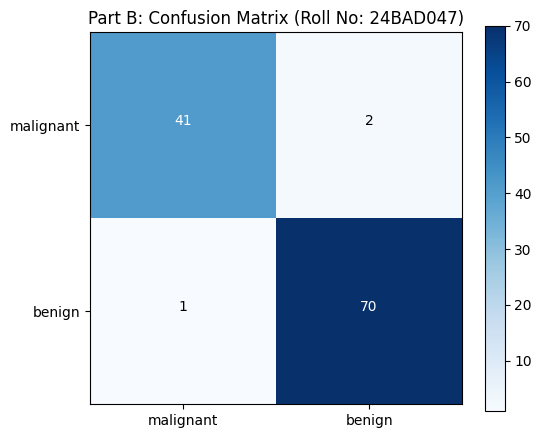

In [12]:
# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f'Part B: Confusion Matrix (Roll No: {STUDENT_ROLL_NO})')
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, data.target_names)
plt.yticks(tick_marks, data.target_names)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, format(cm[i, j], 'd'),
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black"
        )